# BART Variable Importance Comparison

## Setup

In [1]:
from scenario_analysis_helpers import (
    aggregate_experiment_results,
    display_summary_table,
    display_n_selected_summary,
)

from sensitivity_analysis_helpers import (
    aggregate_hyperparameter_results,
    display_hyperparameter_summary,
    aggregate_paired_hyperparameter_results,
    display_paired_summary,
    aggregate_hyperparameter_sensitivity,
    display_sensitivity_comparison,
    plot_hyperparameter_sensitivity,
)

from pathlib import Path
import pandas as pd

In [2]:
RESULTS_DIR = Path("results")
EXPORT_DIR = RESULTS_DIR / "export_tables"
HYPERPARAM_DIR = RESULTS_DIR / "hyperparams_results"

EXPORT_DIR.mkdir(parents=True, exist_ok=True)

## Scenario Experiments

The following experiments compare raw and log-marginal-likelihood-weighted variable importance under the local, global-SE, and global-max permutation thresholds. Global-SE is treated as the primary thresholding method throughout; local and global-max results are shown as supplementary comparisons.

### CC1 - Continuous predictors, continuous response

In the first scenario the Friedman function was used, defined as:
$$
    f(x) = 10 \sin{(\pi x_1 x_2)} + 20(x_3 - 0.5)^2 + 10x_4 + 5x_5,
$$
with $x_1, \dots, x_p \sim Unif(0, 1)$ independent.

In [3]:
cc1_full = pd.read_csv(RESULTS_DIR / "cc1_002.csv")
cc1_summary, cc1_selected = aggregate_experiment_results(cc1_full)

In [4]:
# Primary threshold
display_summary_table(
    cc1_summary,
    "global_se",
    EXPORT_DIR / "cc1_summary.csv",
)

# Alternative thresholds
display_summary_table(cc1_summary, "local")
display_summary_table(cc1_summary, "global_max")

# Number of selected variables
display_n_selected_summary(
    cc1_selected,
    5,
    EXPORT_DIR / "cc1_selected.csv",
)

#### Global-SE threshold

#### Local threshold

#### Global-max threshold

#### Number of selected variables

### CC2 - Continuous predictors, continuous response

For the second continuous-continuous scenario, detection for correlated covariates was compared.

Here $x_1,\dots,x_p$ came from a multivariate normal distribution $N(0, \Sigma)$ where $\Sigma_{ij} = 0.3^{|i - j|}$ and $f$ is defined as:
$$
    f(x) = 2 x_1 x_4 + 2 x_7 x_{10}

$$

In [5]:
cc2_full = pd.read_csv(RESULTS_DIR /"cc2_002.csv")
cc2_summary, cc2_selected = aggregate_experiment_results(cc2_full)

In [6]:
# Primary threshold
display_summary_table(
    cc2_summary,
    "global_se",
    EXPORT_DIR / "cc2_summary.csv",
)

# Alternative thresholds
display_summary_table(cc2_summary, "local")
display_summary_table(cc2_summary, "global_max")

# Number of selected variables
display_n_selected_summary(
    cc2_selected,
    4,
    EXPORT_DIR / "cc2_selected.csv",
)

#### Global-SE threshold

#### Local threshold

#### Global-max threshold

#### Number of selected variables

### CM1 - Mixed predictors, continuous response

In the first scenario, predictors $x_1, \dots, x_{\lceil p/2 \rceil} \sim Bernoulli(0.5)$ independently and $x_{\lceil p/2 \rceil + 1}, \dots, x_p \sim Unif(0, 1)$ independently. Function $f$ is:
$$
    f(x) = 10 \sin{(\pi x_{\lceil p/2 \rceil +1} x_{\lceil p/2 \rceil +2})} + 20(x_{\lceil p/2 \rceil +3} - 0.5)^2 + 10x_1 + 5x_2
$$

Here we consider $n \in \{ 500, 1000 \}$, $p \in \{ 50, 200 \}$ and $\sigma^2 \in \{1, 10\}$.

In [5]:
cm1_full = pd.read_csv(RESULTS_DIR / "cm1_002.csv")
cm1_summary, cm1_selected = aggregate_experiment_results(cm1_full)

In [6]:
# Primary threshold
display_summary_table(
    cm1_summary,
    "global_se",
    EXPORT_DIR / "cm1_summary.csv",
)

# Alternative thresholds
display_summary_table(cm1_summary, "local")
display_summary_table(cm1_summary, "global_max")

# Number of selected variables
display_n_selected_summary(
    cm1_selected,
    5,
    EXPORT_DIR / "cm1_selected.csv",
)

#### Global-SE threshold

#### Local threshold

#### Global-max threshold

#### Number of selected variables

### CM2 - Mixed predictors, continuous response

In this scenario, predictors $x_1, \dots, x_{20} \sim Bernoulli(0.5)$, $x_{21}, \dots, x_{40} \sim Bernoulli(0.5)$ and $x_41, \dots, x_{84} \sim Bernoulli(0.5)$ independently, while $f$ is:
$$
    f(x) = -4 + x_1 + \sin(\pi x_1 x_{44}) - x_{21} + 0.6 x_{41} x_{42} - \exp[-2(x_{42} + 1)^2] - x_{43}^2 + 0.5x_{44}
$$

Here we consider $n \in \{500, 1000\}$ and $\sigma^2 \in \{1, 10\}$.

In [9]:
cm2_full = pd.read_csv(RESULTS_DIR /"cm2_002.csv")
cm2_summary, cm2_selected = aggregate_experiment_results(cm2_full)

In [10]:
# Primary threshold
display_summary_table(
    cm2_summary,
    "global_se",
    EXPORT_DIR / "cm2_summary.csv",
)

# Alternative thresholds
display_summary_table(cm2_summary, "local")
display_summary_table(cm2_summary, "global_max")

# Number of selected variables
display_n_selected_summary(
    cm2_selected,
    6,
    EXPORT_DIR / "cm2_selected.csv",
)

#### Global-SE threshold

#### Local threshold

#### Global-max threshold

#### Number of selected variables

### BM1 - Mixed predictors, binary response

In the first scenario with a binary response, we sample predictors $x_1, \dots, x_{\lceil p/2 \rceil} \sim Bernoulli(0.5)$ independently and $x_{\lceil p/2 \rceil + 1}, \dots, x_p \sim Unif(0, 1)$ independently. We sample the response $y$ from $Bernoulli(\Phi(f(x)))$ where $f$ is the same as in the first mixed-continuous scenario.

In [11]:
bm1_full = pd.read_csv(RESULTS_DIR / "bm1_002.csv")
bm1_summary, bm1_selected = aggregate_experiment_results(bm1_full)

In [12]:
# Primary threshold
display_summary_table(
    bm1_summary,
    "global_se",
    EXPORT_DIR / "bm1_summary.csv",
)

# Alternative thresholds
display_summary_table(bm1_summary, "local")
display_summary_table(bm1_summary, "global_max")

# Number of selected variables
display_n_selected_summary(
    bm1_selected,
    5,
    EXPORT_DIR / "bm1_selected.csv",
)

#### Global-SE threshold

#### Local threshold

#### Global-max threshold

#### Number of selected variables

### BM2 - Mixed predictors, binary response

In this scenario, we sample predictors $x_1, \dots, x_{20} \sim Bernoulli(0.2)$, $x_{21}, \dots, x_{40} \sim Bernoulli(0.5)$ and $x_{41}, \dots, x_{84}$ from a multivariate normal distribution with mean 0, variance 1 and correlation 0.3 independently and response $y$ from  $Bernoulli(\Phi(f(x)))$, where $f$ is the same as in the second mixed-continuous scenario.

In [13]:
bm2_full = pd.read_csv(RESULTS_DIR / "bm2_002.csv")
bm2_summary, bm2_selected = aggregate_experiment_results(bm2_full)

In [14]:
# Primary threshold
display_summary_table(
    bm2_summary,
    "global_se",
    EXPORT_DIR / "bm2_summary.csv",
)

# Alternative thresholds
display_summary_table(bm2_summary, "local")
display_summary_table(bm2_summary, "global_max")

# Number of selected variables
display_n_selected_summary(
    bm2_selected,
    6,
    EXPORT_DIR / "bm2_selected.csv",
)

#### Global-SE threshold

#### Local threshold

#### Global-max threshold

#### Number of selected variables

## Hyperparameter Sensitivity

The following experiments examine the sensitivity of raw and logML-weighted
variable selection to the BART hyperparameters \(m\), \(\beta\), and \(k\).
The reference configuration is \(m=20\), \(\beta=2\), and \(k=2\), with one
hyperparameter varied at a time.

For each scenario, three comparisons are shown:

1. **Performance by configuration** — absolute precision, recall, F1 and related
   quantities at each hyperparameter setting.
2. **Paired change from the reference** — signed changes relative to the reference
   configuration using matched simulation repeats.
3. **Sensitivity to hyperparameters** — the magnitude of the change from the
   reference, together with changes in the selected variable set.

### Continuous predictors scenario - CC1

In [3]:
cont_hyparam = pd.read_csv(HYPERPARAM_DIR / "cc1_001.csv")

cont_summary = aggregate_hyperparameter_results(cont_hyparam)
cont_paired = aggregate_paired_hyperparameter_results(cont_hyparam)
cont_sensitivity = aggregate_hyperparameter_sensitivity(cont_hyparam)

#### Performance by configuration

Absolute variable-selection performance under each hyperparameter configuration.

In [4]:
display_hyperparameter_summary(
    cont_summary,
    "global_se",
    EXPORT_DIR / "cont_summary.csv",
)

#### Paired change from the reference

Signed changes relative to the reference configuration
$(m=20,\beta=2,k=2)$. Positive values indicate an increase relative to
the reference and negative values indicate a decrease.

In [5]:
display_paired_summary(
    cont_paired,
    "global_se",
    EXPORT_DIR / "cont_paired.csv",
)

#### Sensitivity magnitude

Absolute changes from the reference configuration are used here to measure
sensitivity irrespective of whether performance increased or decreased.
Changes in the selected feature set are measured separately using Jaccard
distance.

,Parameter,Value,Recall,F1,r_miss,Selected,Jaccard
0,m,10,-0.09 (0.02),-0.08 (0.01),-16.00 (8.26) pp,-0.58 (0.15),-0.23 (0.03)
1,m,50,+0.01 (0.02),-0.02 (0.01),+4.00 (9.46) pp,-0.12 (0.10),-0.05 (0.02)
2,β,1,-0.02 (0.02),-0.04 (0.01),-8.00 (10.24) pp,-0.32 (0.14),-0.10 (0.02)
3,β,3,-0.07 (0.02),-0.05 (0.01),-22.00 (9.17) pp,-0.76 (0.13),-0.17 (0.03)
4,k,1,-0.03 (0.02),-0.03 (0.01),-14.00 (7.56) pp,-0.44 (0.11),-0.10 (0.03)
5,k,3,-0.02 (0.02),-0.03 (0.01),-6.00 (8.76) pp,-0.38 (0.12),-0.11 (0.03)


*Values are LogML sensitivity minus Raw sensitivity. Positive values indicate greater LogML sensitivity; negative values indicate greater Raw sensitivity. Parentheses contain SEs.*

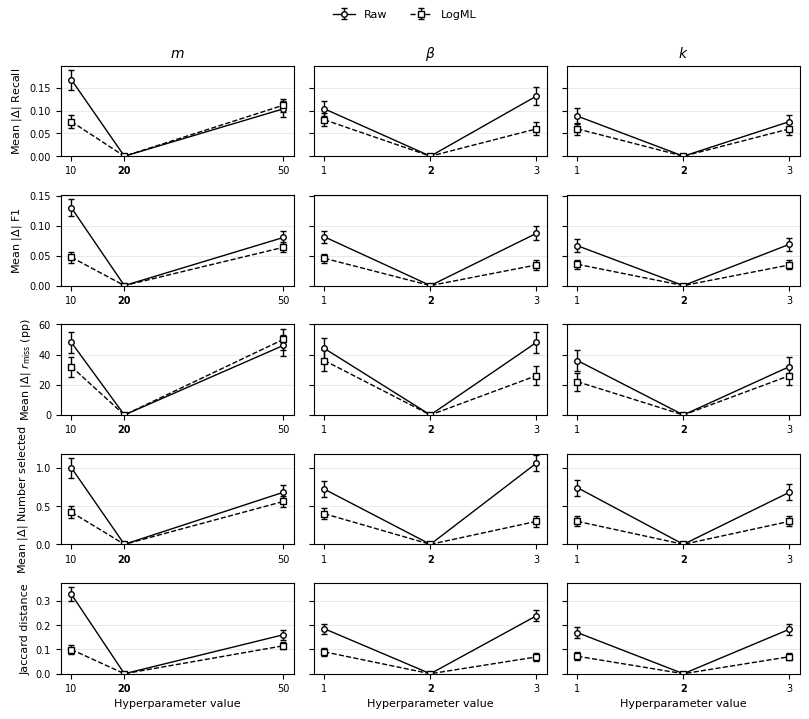

*Raw: solid line with open circles; LogML: dashed line with open squares. Error bars show ±1 SE. Bold x-axis ticks indicate the reference hyperparameter value.*

In [5]:
display_sensitivity_comparison(
    cont_sensitivity,
    "global_se",
    output_path=EXPORT_DIR / "cont_sensitivity.csv",
)

plot_hyperparameter_sensitivity(
    cont_sensitivity,
    "global_se",
)

### Mixed predictors scenario - CM2

In [ ]:
mix_hyparam = pd.read_csv(HYPERPARAM_DIR / "cm2.csv")

mix_summary = aggregate_hyperparameter_results(mix_hyparam)
mix_paired = aggregate_paired_hyperparameter_results(mix_hyparam)
mix_sensitivity = aggregate_hyperparameter_sensitivity(mix_hyparam)

#### Performance by configuration

Absolute variable-selection performance under each hyperparameter configuration.

In [ ]:
display_hyperparameter_summary(
    mix_summary,
    "global_se",
    EXPORT_DIR / "mix_summary.csv",
)

,Parameter,Value,Precision Raw,Precision LogML,Recall Raw,Recall LogML,F1 Raw,F1 LogML,r_miss Raw,r_miss LogML
0,m,10.000000,0.89 (0.02),0.98 (0.01),0.78 (0.03),0.86 (0.02),0.82 (0.02),0.91 (0.01),74%,64%
1,m,20.000000,0.95 (0.01),1.00 (0.00),0.90 (0.02),0.85 (0.01),0.92 (0.01),0.91 (0.01),46%,72%
2,m,50.000000,0.97 (0.01),1.00 (0.00),1.00 (0.00),0.95 (0.01),0.99 (0.01),0.97 (0.01),0%,22%
3,β,1.000000,0.96 (0.01),1.00 (0.00),0.95 (0.01),0.88 (0.02),0.95 (0.01),0.93 (0.01),22%,56%
4,β,2.000000,0.95 (0.01),1.00 (0.00),0.90 (0.02),0.85 (0.01),0.92 (0.01),0.91 (0.01),46%,72%
5,β,3.000000,0.95 (0.01),1.00 (0.00),0.86 (0.02),0.85 (0.01),0.89 (0.01),0.92 (0.01),58%,70%
6,k,1.000000,0.96 (0.01),1.00 (0.00),0.91 (0.02),0.84 (0.02),0.93 (0.01),0.91 (0.01),42%,74%
7,k,2.000000,0.95 (0.01),1.00 (0.00),0.90 (0.02),0.85 (0.01),0.92 (0.01),0.91 (0.01),46%,72%
8,k,3.000000,0.95 (0.01),1.00 (0.00),0.92 (0.02),0.87 (0.02),0.93 (0.01),0.93 (0.01),38%,62%


#### Paired change from the reference

Signed changes relative to the reference configuration
$(m=20,\beta=2,k=2)$. Positive values indicate an increase relative to
the reference and negative values indicate a decrease.

,Parameter,Value,Δ Precision Raw,Δ Precision LogML,Δ Recall Raw,Δ Recall LogML,Δ F1 Raw,Δ F1 LogML,Δ r_miss Raw,Selected Raw,Δ TP Raw,Δ FP Raw,Jaccard dist. Raw,Δ r_miss LogML,Selected LogML,Δ TP LogML,Δ FP LogML,Jaccard dist. LogML
0,m,10,-0.06 (0.02),-0.02 (0.01),-0.12 (0.03),+0.01 (0.02),-0.10 (0.02),-0.00 (0.01),+28.0 pp (9.1),4.76 -0.36 (0.18),-0.60 (0.14),+0.24 (0.11),0.33 (0.03),-8.0 pp (8.0),4.24 +0.14 (0.10),+0.06 (0.09),+0.08 (0.04),0.10 (0.02)
1,m,50,+0.02 (0.01),+0.00 (0.00),+0.10 (0.02),+0.10 (0.02),+0.07 (0.01),+0.06 (0.01),-46.0 pp (7.1),4.76 +0.40 (0.13),+0.52 (0.09),-0.12 (0.09),0.16 (0.02),-50.0 pp (7.1),4.24 +0.52 (0.08),+0.52 (0.08),+0.00 (0.00),0.11 (0.01)
2,β,1,+0.01 (0.02),+0.00 (0.00),+0.06 (0.02),+0.03 (0.02),+0.03 (0.01),+0.02 (0.01),-24.0 pp (8.8),4.76 +0.28 (0.14),+0.28 (0.10),+0.00 (0.09),0.19 (0.02),-16.0 pp (8.3),4.24 +0.16 (0.09),+0.16 (0.09),+0.00 (0.00),0.09 (0.02)
3,β,3,-0.00 (0.02),+0.00 (0.00),-0.04 (0.03),+0.00 (0.02),-0.02 (0.02),+0.00 (0.01),+12.0 pp (9.7),4.76 -0.14 (0.19),-0.18 (0.13),+0.04 (0.10),0.24 (0.02),-2.0 pp (7.3),4.24 +0.02 (0.08),+0.02 (0.08),+0.00 (0.00),0.07 (0.02)
4,k,1,+0.01 (0.02),+0.00 (0.00),+0.02 (0.02),-0.01 (0.02),+0.02 (0.01),-0.01 (0.01),-4.0 pp (8.6),4.76 +0.02 (0.15),+0.08 (0.11),-0.06 (0.09),0.17 (0.02),+2.0 pp (6.7),4.24 -0.06 (0.08),-0.06 (0.08),+0.00 (0.00),0.07 (0.02)
5,k,3,-0.00 (0.02),+0.00 (0.00),+0.02 (0.02),+0.02 (0.02),+0.01 (0.01),+0.01 (0.01),-8.0 pp (8.0),4.76 +0.12 (0.14),+0.10 (0.09),+0.02 (0.11),0.18 (0.02),-10.0 pp (7.1),4.24 +0.10 (0.08),+0.10 (0.08),+0.00 (0.00),0.07 (0.02)


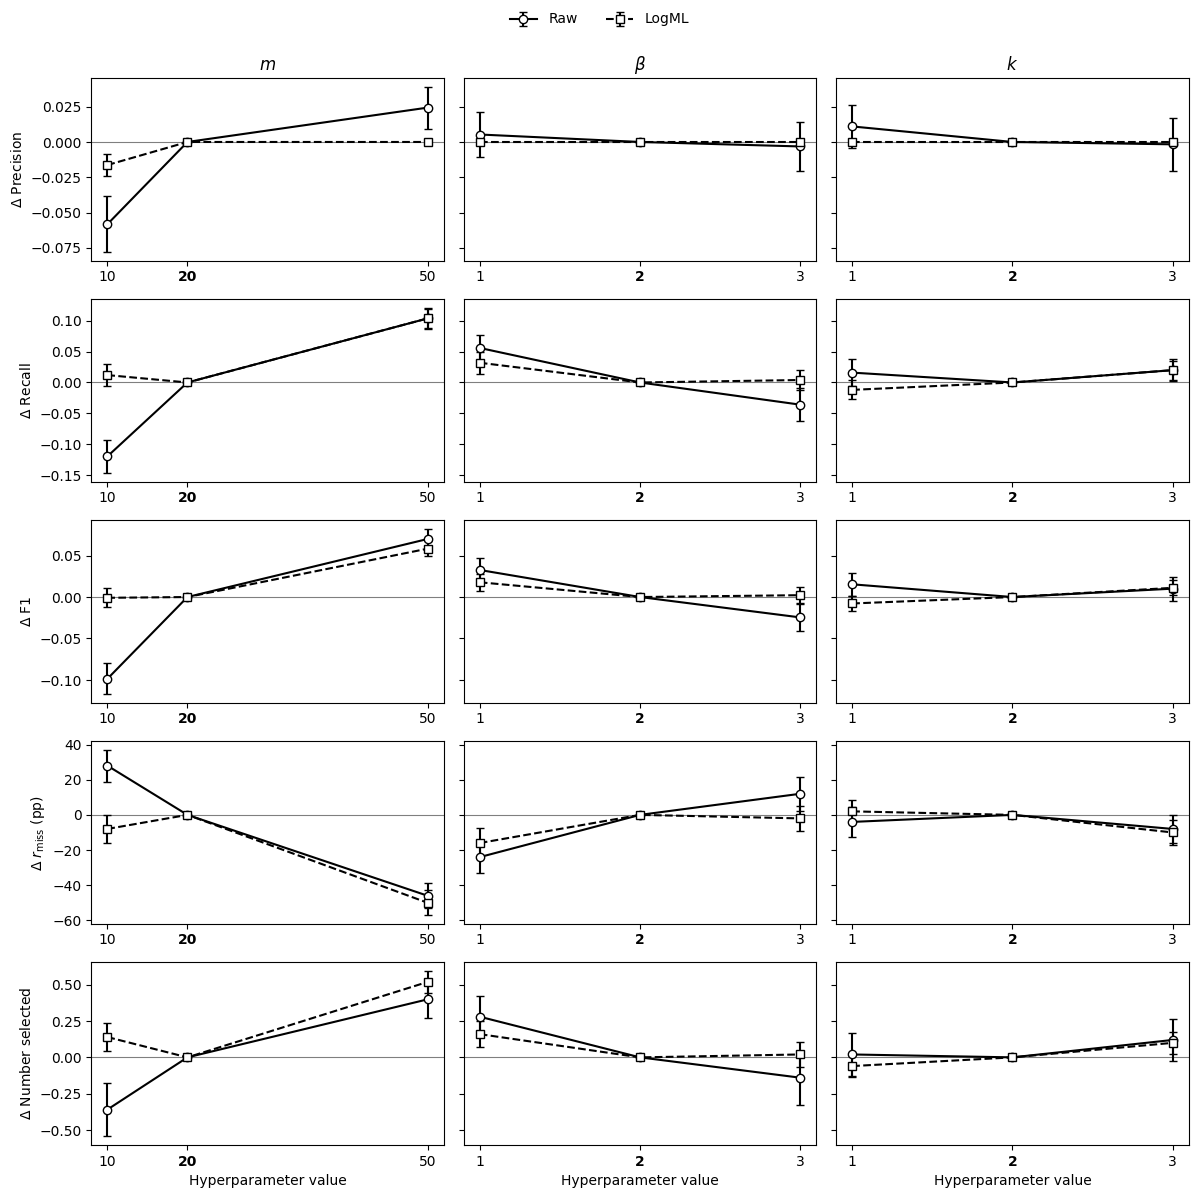

In [ ]:
display_paired_summary(
    mix_paired,
    "global_se",
    EXPORT_DIR / "mix_paired.csv",
)

#### Sensitivity magnitude

Absolute changes from the reference configuration are used here to measure
sensitivity irrespective of whether performance increased or decreased.
Changes in the selected feature set are measured separately using Jaccard
distance.

,Parameter,Value,|Δ| Raw,|Δ| LogML,LogML − Raw
0,m,10,0.13 (0.01),0.05 (0.01),-0.08 (0.01)
1,m,50,0.08 (0.01),0.06 (0.01),-0.02 (0.01)
2,β,1,0.08 (0.01),0.05 (0.01),-0.04 (0.01)
3,β,3,0.09 (0.01),0.03 (0.01),-0.05 (0.01)
4,k,1,0.07 (0.01),0.04 (0.01),-0.03 (0.01)
5,k,3,0.07 (0.01),0.03 (0.01),-0.03 (0.01)


,Parameter,Value,|Δ Selected| Raw,Jaccard dist. Raw,|Δ Selected| LogML,Jaccard dist. LogML,Selected LogML − Raw,Jaccard LogML − Raw
0,m,10,1.00 (0.13),0.33 (0.03),0.42 (0.08),0.10 (0.02),-0.58 (0.15),-0.23 (0.03)
1,m,50,0.68 (0.10),0.16 (0.02),0.56 (0.07),0.11 (0.01),-0.12 (0.10),-0.05 (0.02)
2,β,1,0.72 (0.10),0.19 (0.02),0.40 (0.07),0.09 (0.02),-0.32 (0.14),-0.10 (0.02)
3,β,3,1.06 (0.11),0.24 (0.02),0.30 (0.07),0.07 (0.02),-0.76 (0.13),-0.17 (0.03)
4,k,1,0.74 (0.11),0.17 (0.02),0.30 (0.07),0.07 (0.02),-0.44 (0.11),-0.10 (0.03)
5,k,3,0.68 (0.10),0.18 (0.02),0.30 (0.07),0.07 (0.02),-0.38 (0.12),-0.11 (0.03)


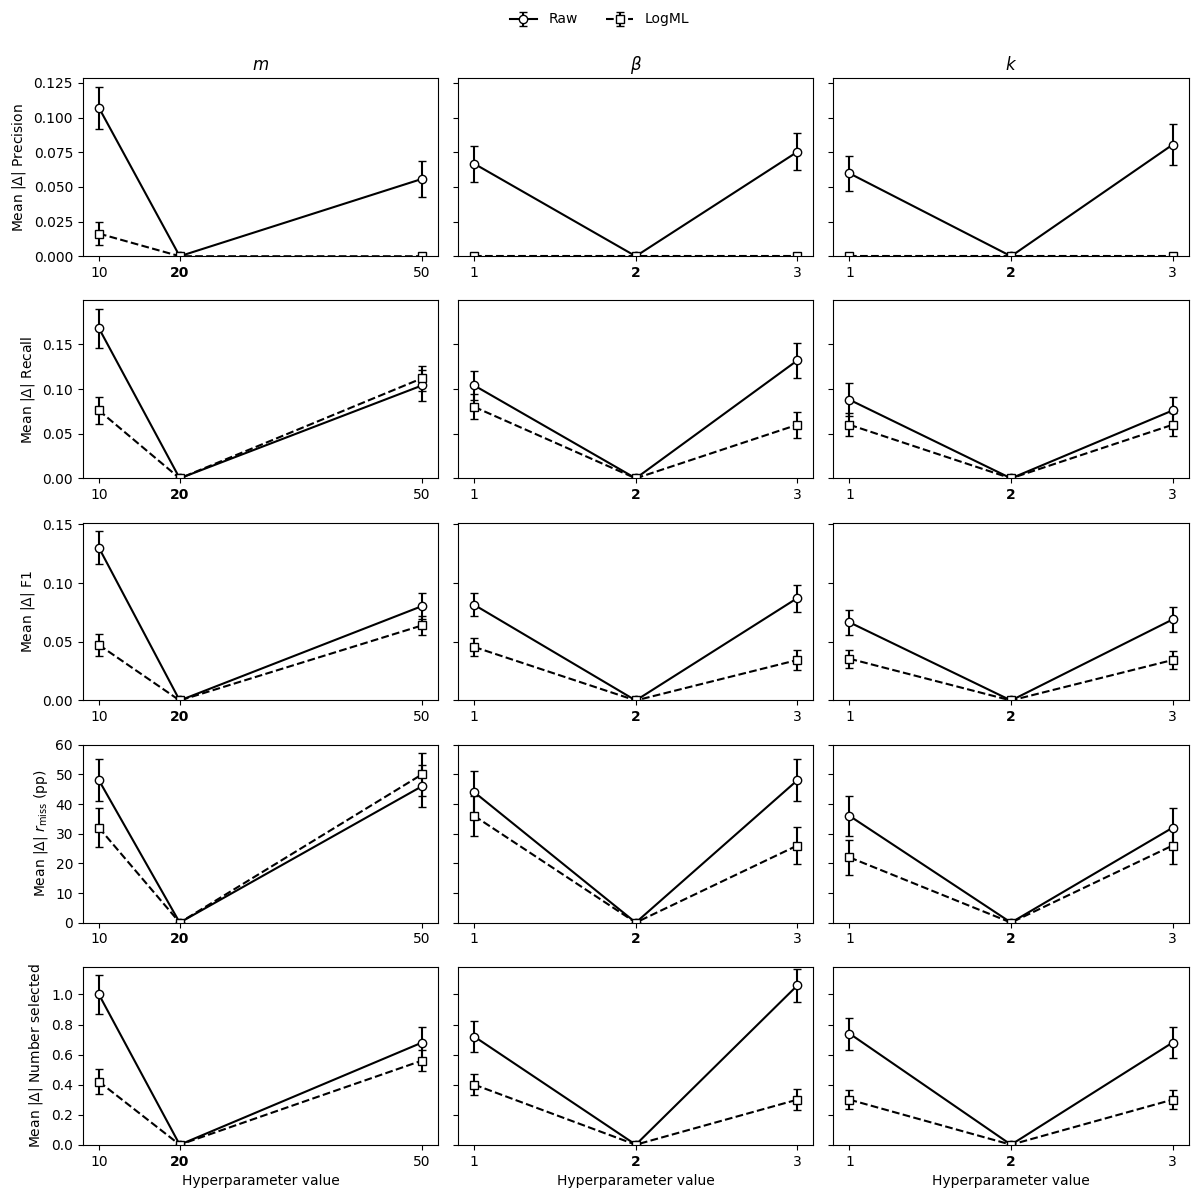

In [ ]:
display_sensitivity_comparison(
    mix_sensitivity,
    "global_se",
    output_path=EXPORT_DIR / "mix_sensitivity.csv",
)

plot_hyperparameter_sensitivity(
    mix_sensitivity,
    "global_se",
)

### Binary-response scenario - BM1

In [ ]:
bin_hyparam = pd.read_csv(HYPERPARAM_DIR / "bm1.csv")

bin_summary = aggregate_hyperparameter_results(bin_hyparam)
bin_paired = aggregate_paired_hyperparameter_results(bin_hyparam)
bin_sensitivity = aggregate_hyperparameter_sensitivity(bin_hyparam)

#### Performance by configuration

Absolute variable-selection performance under each hyperparameter configuration.

In [ ]:
display_hyperparameter_summary(
    bin_summary,
    "global_se",
    EXPORT_DIR / "bin_summary.csv",
)

,Parameter,Value,Precision Raw,Precision LogML,Recall Raw,Recall LogML,F1 Raw,F1 LogML,r_miss Raw,r_miss LogML
0,m,10.000000,0.89 (0.02),0.98 (0.01),0.78 (0.03),0.86 (0.02),0.82 (0.02),0.91 (0.01),74%,64%
1,m,20.000000,0.95 (0.01),1.00 (0.00),0.90 (0.02),0.85 (0.01),0.92 (0.01),0.91 (0.01),46%,72%
2,m,50.000000,0.97 (0.01),1.00 (0.00),1.00 (0.00),0.95 (0.01),0.99 (0.01),0.97 (0.01),0%,22%
3,β,1.000000,0.96 (0.01),1.00 (0.00),0.95 (0.01),0.88 (0.02),0.95 (0.01),0.93 (0.01),22%,56%
4,β,2.000000,0.95 (0.01),1.00 (0.00),0.90 (0.02),0.85 (0.01),0.92 (0.01),0.91 (0.01),46%,72%
5,β,3.000000,0.95 (0.01),1.00 (0.00),0.86 (0.02),0.85 (0.01),0.89 (0.01),0.92 (0.01),58%,70%
6,k,1.000000,0.96 (0.01),1.00 (0.00),0.91 (0.02),0.84 (0.02),0.93 (0.01),0.91 (0.01),42%,74%
7,k,2.000000,0.95 (0.01),1.00 (0.00),0.90 (0.02),0.85 (0.01),0.92 (0.01),0.91 (0.01),46%,72%
8,k,3.000000,0.95 (0.01),1.00 (0.00),0.92 (0.02),0.87 (0.02),0.93 (0.01),0.93 (0.01),38%,62%


#### Paired change from the reference

Signed changes relative to the reference configuration
$(m=20,\beta=2,k=2)$. Positive values indicate an increase relative to
the reference and negative values indicate a decrease.

,Parameter,Value,Δ Precision Raw,Δ Precision LogML,Δ Recall Raw,Δ Recall LogML,Δ F1 Raw,Δ F1 LogML,Δ r_miss Raw,Selected Raw,Δ TP Raw,Δ FP Raw,Jaccard dist. Raw,Δ r_miss LogML,Selected LogML,Δ TP LogML,Δ FP LogML,Jaccard dist. LogML
0,m,10,-0.06 (0.02),-0.02 (0.01),-0.12 (0.03),+0.01 (0.02),-0.10 (0.02),-0.00 (0.01),+28.0 pp (9.1),4.76 -0.36 (0.18),-0.60 (0.14),+0.24 (0.11),0.33 (0.03),-8.0 pp (8.0),4.24 +0.14 (0.10),+0.06 (0.09),+0.08 (0.04),0.10 (0.02)
1,m,50,+0.02 (0.01),+0.00 (0.00),+0.10 (0.02),+0.10 (0.02),+0.07 (0.01),+0.06 (0.01),-46.0 pp (7.1),4.76 +0.40 (0.13),+0.52 (0.09),-0.12 (0.09),0.16 (0.02),-50.0 pp (7.1),4.24 +0.52 (0.08),+0.52 (0.08),+0.00 (0.00),0.11 (0.01)
2,β,1,+0.01 (0.02),+0.00 (0.00),+0.06 (0.02),+0.03 (0.02),+0.03 (0.01),+0.02 (0.01),-24.0 pp (8.8),4.76 +0.28 (0.14),+0.28 (0.10),+0.00 (0.09),0.19 (0.02),-16.0 pp (8.3),4.24 +0.16 (0.09),+0.16 (0.09),+0.00 (0.00),0.09 (0.02)
3,β,3,-0.00 (0.02),+0.00 (0.00),-0.04 (0.03),+0.00 (0.02),-0.02 (0.02),+0.00 (0.01),+12.0 pp (9.7),4.76 -0.14 (0.19),-0.18 (0.13),+0.04 (0.10),0.24 (0.02),-2.0 pp (7.3),4.24 +0.02 (0.08),+0.02 (0.08),+0.00 (0.00),0.07 (0.02)
4,k,1,+0.01 (0.02),+0.00 (0.00),+0.02 (0.02),-0.01 (0.02),+0.02 (0.01),-0.01 (0.01),-4.0 pp (8.6),4.76 +0.02 (0.15),+0.08 (0.11),-0.06 (0.09),0.17 (0.02),+2.0 pp (6.7),4.24 -0.06 (0.08),-0.06 (0.08),+0.00 (0.00),0.07 (0.02)
5,k,3,-0.00 (0.02),+0.00 (0.00),+0.02 (0.02),+0.02 (0.02),+0.01 (0.01),+0.01 (0.01),-8.0 pp (8.0),4.76 +0.12 (0.14),+0.10 (0.09),+0.02 (0.11),0.18 (0.02),-10.0 pp (7.1),4.24 +0.10 (0.08),+0.10 (0.08),+0.00 (0.00),0.07 (0.02)


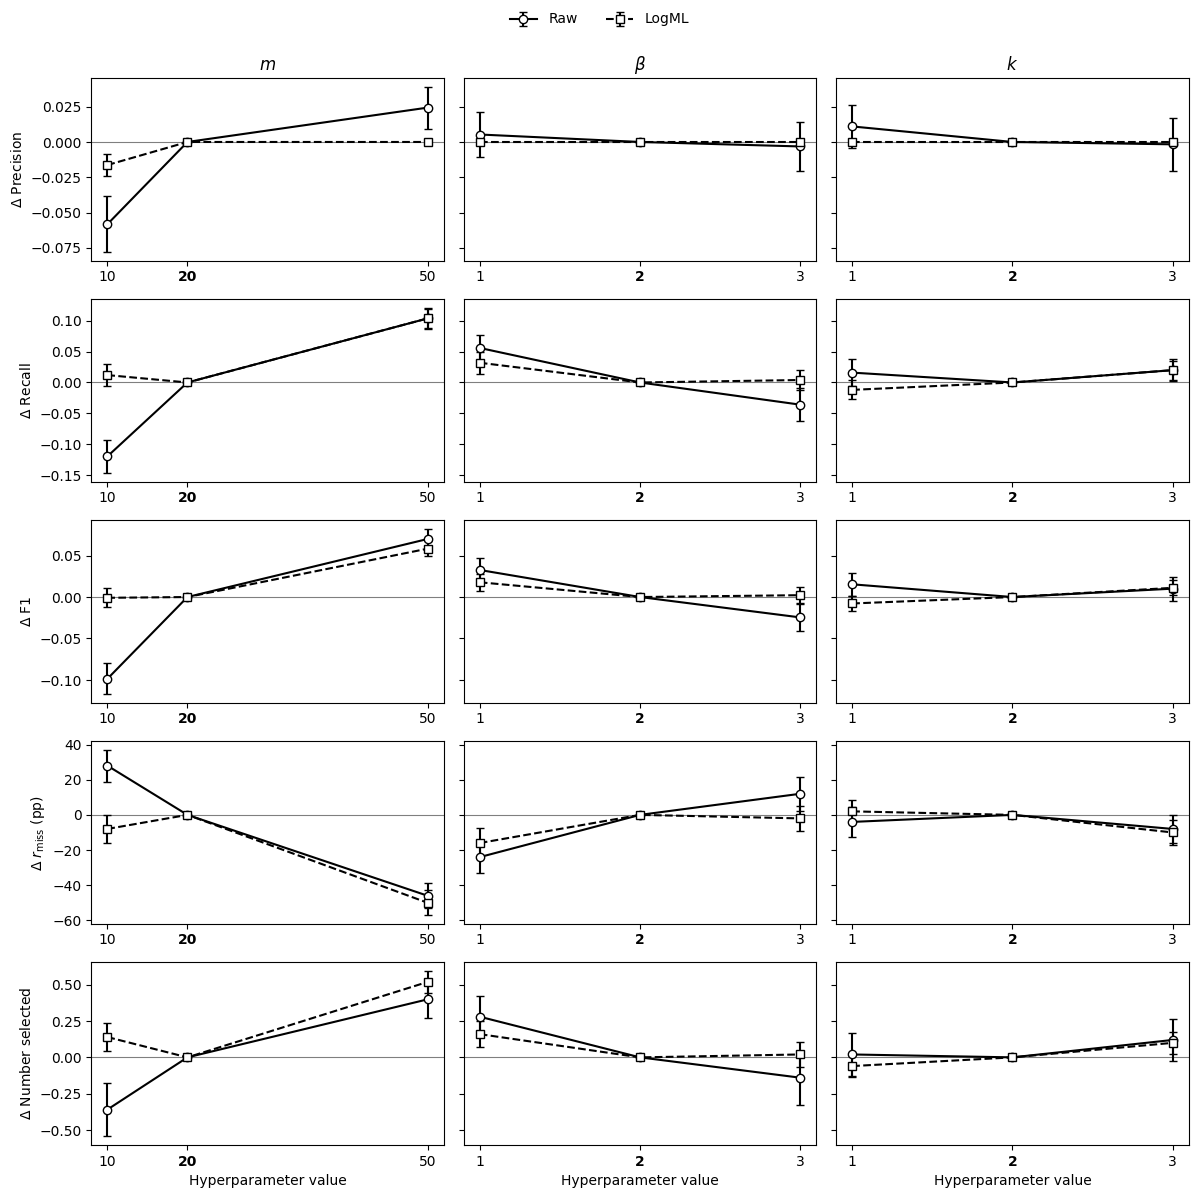

In [ ]:
display_paired_summary(
    bin_paired,
    "global_se",
    EXPORT_DIR / "bin_paired.csv",
)

#### Sensitivity magnitude

Absolute changes from the reference configuration are used here to measure
sensitivity irrespective of whether performance increased or decreased.
Changes in the selected feature set are measured separately using Jaccard
distance.

,Parameter,Value,|Δ| Raw,|Δ| LogML,LogML − Raw
0,m,10,0.13 (0.01),0.05 (0.01),-0.08 (0.01)
1,m,50,0.08 (0.01),0.06 (0.01),-0.02 (0.01)
2,β,1,0.08 (0.01),0.05 (0.01),-0.04 (0.01)
3,β,3,0.09 (0.01),0.03 (0.01),-0.05 (0.01)
4,k,1,0.07 (0.01),0.04 (0.01),-0.03 (0.01)
5,k,3,0.07 (0.01),0.03 (0.01),-0.03 (0.01)


,Parameter,Value,|Δ Selected| Raw,Jaccard dist. Raw,|Δ Selected| LogML,Jaccard dist. LogML,Selected LogML − Raw,Jaccard LogML − Raw
0,m,10,1.00 (0.13),0.33 (0.03),0.42 (0.08),0.10 (0.02),-0.58 (0.15),-0.23 (0.03)
1,m,50,0.68 (0.10),0.16 (0.02),0.56 (0.07),0.11 (0.01),-0.12 (0.10),-0.05 (0.02)
2,β,1,0.72 (0.10),0.19 (0.02),0.40 (0.07),0.09 (0.02),-0.32 (0.14),-0.10 (0.02)
3,β,3,1.06 (0.11),0.24 (0.02),0.30 (0.07),0.07 (0.02),-0.76 (0.13),-0.17 (0.03)
4,k,1,0.74 (0.11),0.17 (0.02),0.30 (0.07),0.07 (0.02),-0.44 (0.11),-0.10 (0.03)
5,k,3,0.68 (0.10),0.18 (0.02),0.30 (0.07),0.07 (0.02),-0.38 (0.12),-0.11 (0.03)


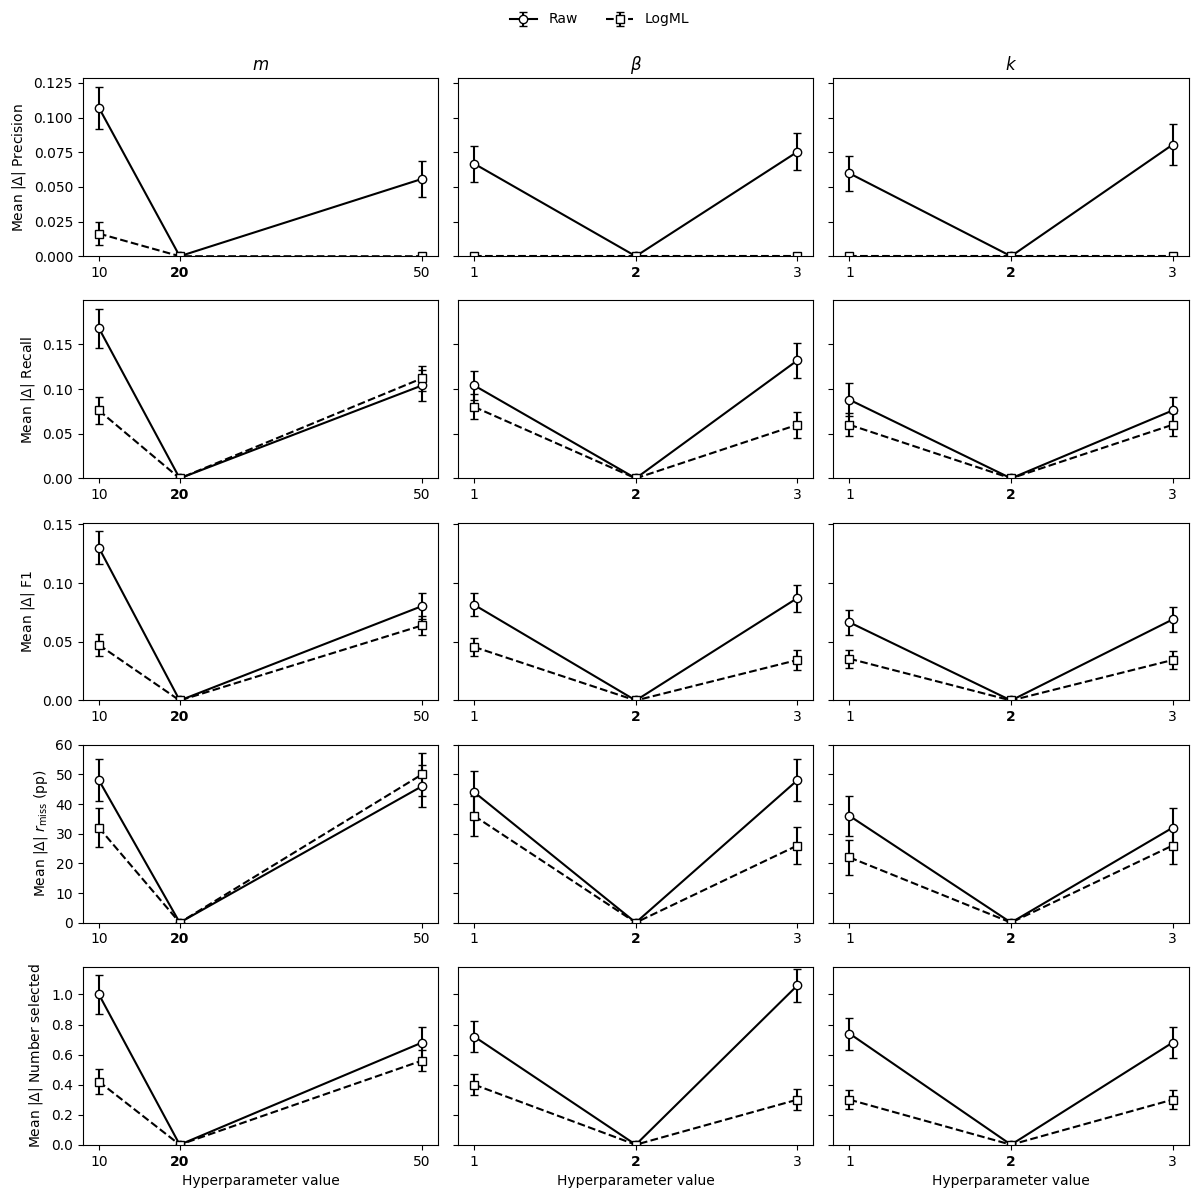

In [ ]:
display_sensitivity_comparison(
    bin_sensitivity,
    "global_se",
    output_path=EXPORT_DIR / "bin_sensitivity.csv",
)

plot_hyperparameter_sensitivity(
    bin_sensitivity,
    "global_se",
)